# Análisis exploratorio de datos (EDA)

**Datos:** Telco Customer Churn, 7.043 clientes de una empresa de telecomunicaciones. Cada fila es un cliente, con sus datos demográficos, los servicios contratados, su facturación y si canceló el servicio (`Churn`).

**Objetivo de este notebook:** entender los datos antes de modelar.

1. Revisar la calidad de los datos.
2. Conocer la variable objetivo.
3. Ver qué variables se relacionan con la cancelación.
4. Decidir qué variables entran al modelo.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

AZUL, NARANJA = "#2a78d6", "#eb6834"
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

## 1. Carga y primera revisión

In [2]:
df = pd.read_csv("../data/telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

`TotalCharges` debería ser numérica, pero se cargó como texto. Eso indica que hay valores que no son números.

## 2. Calidad de los datos

### 2.1 Valores vacíos en `TotalCharges`

In [5]:
# Celdas que contienen solo un espacio en blanco, por columna
(df == " ").sum().loc[lambda s: s > 0]

TotalCharges    11
dtype: int64

In [6]:
df[df["TotalCharges"] == " "][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Los 11 casos son clientes con `tenure = 0`: acaban de llegar y todavía no tienen ningún cobro acumulado. No es un error de captura, así que no se eliminan: se convierte la columna a número y los vacíos se reemplazan por 0.

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Nulos tras convertir:", df["TotalCharges"].isnull().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Nulos tras reemplazar:", df["TotalCharges"].isnull().sum())

Nulos tras convertir: 11
Nulos tras reemplazar: 0


In [8]:
df.isnull().sum().sum()

np.int64(0)

### 2.2 Duplicados

In [9]:
print("Filas duplicadas:", df.duplicated().sum())
print("Filas que coinciden si se ignora el identificador:", df.drop(columns=["customerID"]).duplicated().sum())

Filas duplicadas: 0
Filas que coinciden si se ignora el identificador: 22


No hay clientes repetidos. Las 22 filas que coinciden al ignorar `customerID` son clientes distintos con el mismo perfil (por ejemplo, recién llegados con el plan más básico), así que se conservan.

### 2.3 Valores atípicos

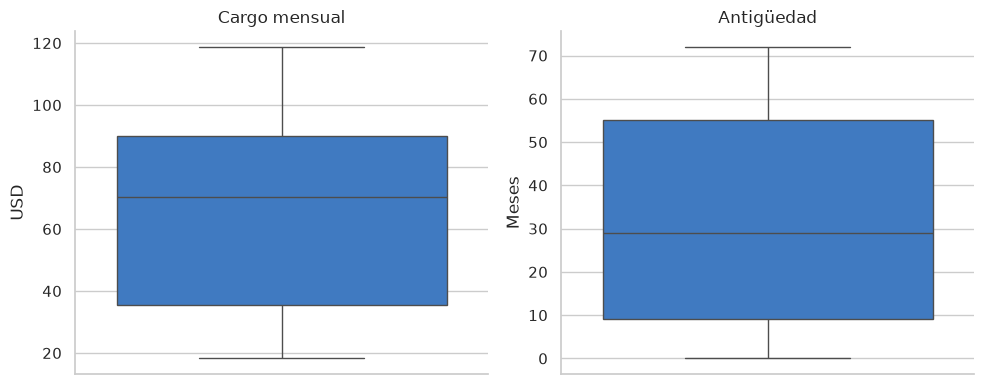

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(y=df["MonthlyCharges"], color=AZUL, ax=axes[0])
axes[0].set(title="Cargo mensual", ylabel="USD")

sns.boxplot(y=df["tenure"], color=AZUL, ax=axes[1])
axes[1].set(title="Antigüedad", ylabel="Meses")

plt.tight_layout()
plt.show()

Ninguna de las dos variables tiene valores atípicos.

## 3. Variable objetivo

In [11]:
df["Churn"].value_counts(normalize=True).round(3)

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

Canceló el 26,5 % de los clientes. Las clases están desbalanceadas: un modelo que predijera siempre "no cancela" acertaría el 73,5 % de las veces sin servir para nada. Por eso los modelos se entrenan con clases balanceadas y se evalúan con recall, precisión y F1, no con *accuracy*.

## 4. Variables numéricas

In [12]:
df["Churn_encoded"] = df["Churn"].map({"Yes": 1, "No": 0})

df[["tenure", "MonthlyCharges", "TotalCharges", "Churn_encoded"]].corr().round(3)

,tenure,MonthlyCharges,TotalCharges,Churn_encoded
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.198
Churn_encoded,-0.352,0.193,-0.198,1.000


- `tenure` es la variable numérica más relacionada con la cancelación (correlación negativa): a más antigüedad, menos cancelaciones.
- `MonthlyCharges` tiene una relación positiva más débil: quienes pagan más cancelan algo más.
- `TotalCharges` está muy correlacionada con `tenure` (0,83), lo cual es esperable porque es aproximadamente antigüedad × cargo mensual. Aporta poca información nueva. Se conserva porque los modelos de árbol no se ven afectados por variables correlacionadas, pero hay que tenerlo presente al interpretar un modelo lineal.

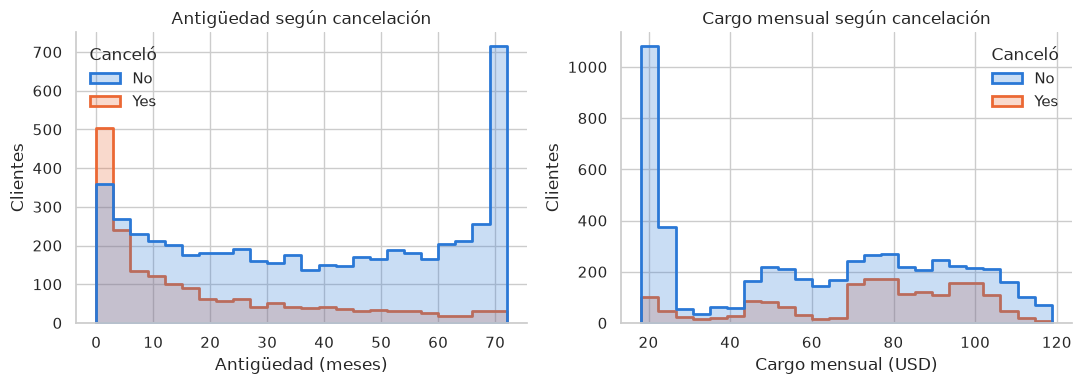

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
orden_churn, paleta = ["No", "Yes"], {"No": AZUL, "Yes": NARANJA}

sns.histplot(data=df, x="tenure", hue="Churn", hue_order=orden_churn, palette=paleta,
             bins=24, element="step", alpha=0.25, linewidth=2, ax=axes[0])
axes[0].set(title="Antigüedad según cancelación", xlabel="Antigüedad (meses)", ylabel="Clientes")

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", hue_order=orden_churn, palette=paleta,
             bins=24, element="step", alpha=0.25, linewidth=2, ax=axes[1])
axes[1].set(title="Cargo mensual según cancelación", xlabel="Cargo mensual (USD)", ylabel="Clientes")

for ax in axes:
    ax.get_legend().set_title("Canceló")
    ax.get_legend().set_frame_on(False)

plt.tight_layout()
plt.show()

Las cancelaciones se concentran en los primeros meses de relación y en los clientes con cargos mensuales entre 70 y 100 USD.

In [14]:
tramos = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                labels=["0-12 meses", "13-24 meses", "25-48 meses", "Más de 48 meses"])

churn_por_antiguedad = (df.groupby(tramos, observed=True)["Churn_encoded"]
                          .agg(clientes="count", tasa_churn_pct="mean"))
churn_por_antiguedad["tasa_churn_pct"] = (churn_por_antiguedad["tasa_churn_pct"] * 100).round(1)
churn_por_antiguedad

,clientes,tasa_churn_pct
tenure,,
0-12 meses,2186,47.4
13-24 meses,1024,28.7
25-48 meses,1594,20.4
Más de 48 meses,2239,9.5


## 5. Variables categóricas

### 5.1 Relación de cada variable con la cancelación

Para medir la asociación entre dos variables categóricas se usa la **V de Cramér**, que va de 0 (sin relación) a 1 (relación perfecta). Es el equivalente de la correlación para variables categóricas y se calcula a partir del estadístico chi-cuadrado.

In [15]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    min_dim = min(tabla.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

In [16]:
# Variables categóricas, sin el identificador ni el objetivo
categoricas = df.select_dtypes(exclude="number").columns.drop(["customerID", "Churn"])

relacion_con_churn = pd.Series(
    {col: cramers_v(df[col], df["Churn"]) for col in categoricas}
).sort_values(ascending=False)

relacion_con_churn.round(3)

Contract            0.410
OnlineSecurity      0.347
TechSupport         0.343
InternetService     0.322
PaymentMethod       0.303
OnlineBackup        0.292
DeviceProtection    0.282
StreamingMovies     0.231
StreamingTV         0.231
PaperlessBilling    0.191
Dependents          0.164
Partner             0.150
MultipleLines       0.040
PhoneService        0.011
gender              0.008
dtype: float64

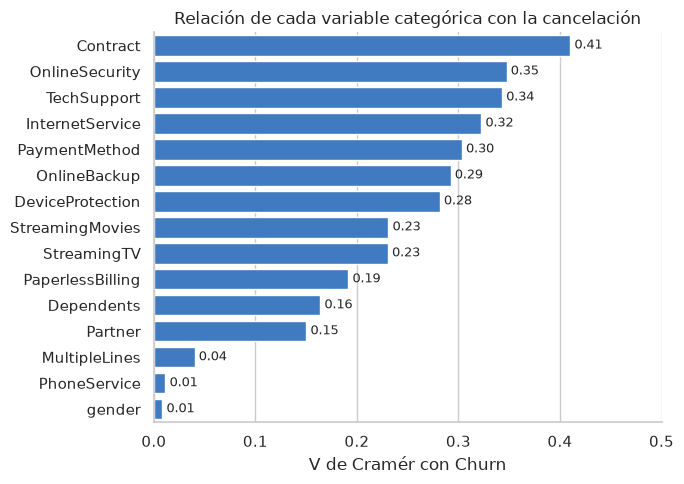

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=relacion_con_churn.values, y=relacion_con_churn.index, color=AZUL, ax=ax)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=9)
ax.set(xlabel="V de Cramér con Churn", ylabel="", title="Relación de cada variable categórica con la cancelación", xlim=(0, 0.5))
plt.tight_layout()
plt.show()

- El **tipo de contrato** es la variable más relacionada con la cancelación.
- `gender`, `PhoneService` y `MultipleLines` prácticamente no tienen relación (V menor que 0,05).

### 5.2 Tasa de cancelación en las variables más relevantes

In [18]:
def tasa_churn(columna):
    tabla = df.groupby(columna)["Churn_encoded"].agg(clientes="count", tasa_churn_pct="mean")
    tabla["tasa_churn_pct"] = (tabla["tasa_churn_pct"] * 100).round(1)
    return tabla.sort_values("tasa_churn_pct", ascending=False)

for columna in ["Contract", "InternetService", "PaymentMethod"]:
    display(tasa_churn(columna))

,clientes,tasa_churn_pct
Contract,,
Month-to-month,3875,42.7
One year,1473,11.3
Two year,1695,2.8


,clientes,tasa_churn_pct
InternetService,,
Fiber optic,3096,41.9
DSL,2421,19.0
No,1526,7.4


,clientes,tasa_churn_pct
PaymentMethod,,
Electronic check,2365,45.3
Mailed check,1612,19.1
Bank transfer (automatic),1544,16.7
Credit card (automatic),1522,15.2


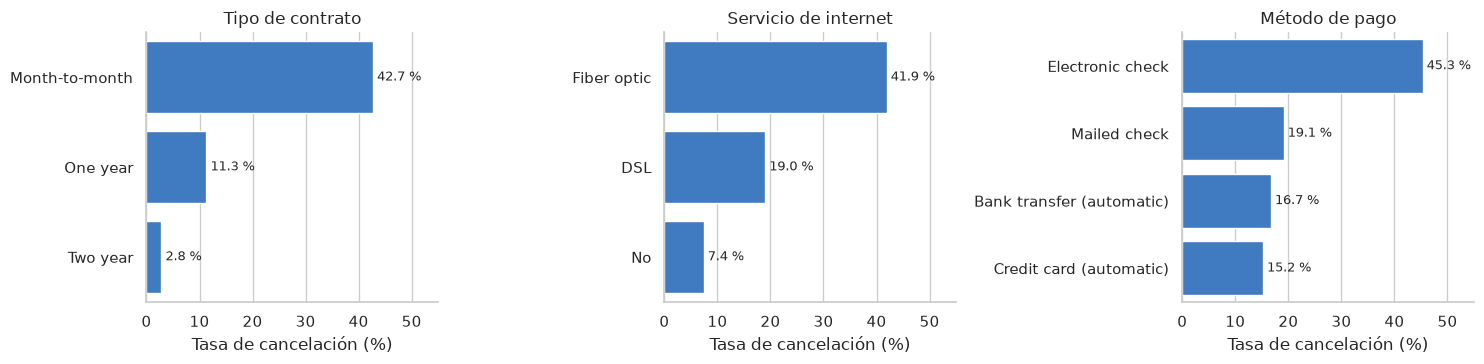

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
titulos = {"Contract": "Tipo de contrato", "InternetService": "Servicio de internet", "PaymentMethod": "Método de pago"}

for ax, (columna, titulo) in zip(axes, titulos.items()):
    tabla = tasa_churn(columna)
    sns.barplot(x=tabla["tasa_churn_pct"], y=tabla.index, color=AZUL, ax=ax)
    ax.bar_label(ax.containers[0], fmt="%.1f %%", padding=3, fontsize=9)
    ax.set(title=titulo, xlabel="Tasa de cancelación (%)", ylabel="", xlim=(0, 55))

plt.tight_layout()
plt.savefig("../img/eda_tasa_churn.png", dpi=150, facecolor="white")
plt.show()

### 5.3 Relación entre las variables categóricas

La misma medida, ahora entre cada par de variables, para detectar información repetida.

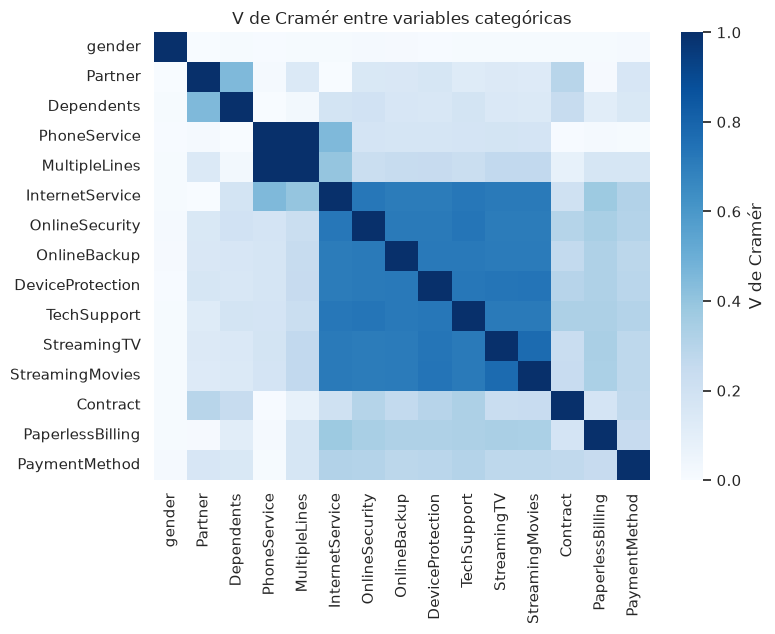

In [20]:
matriz_cramers = pd.DataFrame(index=categoricas, columns=categoricas, dtype=float)

for col1 in categoricas:
    for col2 in categoricas:
        matriz_cramers.loc[col1, col2] = cramers_v(df[col1], df[col2])

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(matriz_cramers.astype(float), cmap="Blues", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "V de Cramér"})
ax.set_title("V de Cramér entre variables categóricas")
plt.tight_layout()
plt.show()

Los servicios que dependen de tener internet (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) están muy relacionados entre sí y con `InternetService`: todos comparten la categoría *No internet service*. Lo mismo pasa entre `PhoneService` y `MultipleLines`.

## 6. Selección de variables

Con lo anterior se toman tres decisiones:

1. **Eliminar** `gender`, `PhoneService` y `MultipleLines`, por no tener relación con la cancelación.
2. **Resumir** los cuatro servicios con menor relación dentro de su grupo (`OnlineBackup`, `DeviceProtection`, `StreamingTV`, `StreamingMovies`) en una sola variable, `cantidad_servicios`: cuántos de ellos tiene contratados el cliente.
3. **Conservar** por separado `OnlineSecurity` y `TechSupport`, que son los servicios más relacionados con la cancelación.

In [21]:
df_modelo = df.drop(columns=["gender", "MultipleLines", "PhoneService"])

servicios_a_resumir = ["OnlineBackup", "DeviceProtection", "StreamingTV", "StreamingMovies"]
df_modelo["cantidad_servicios"] = (df_modelo[servicios_a_resumir] == "Yes").sum(axis=1)
df_modelo = df_modelo.drop(columns=servicios_a_resumir)

print(df_modelo.drop(columns=["customerID", "Churn", "Churn_encoded"]).columns.tolist())

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'cantidad_servicios']


In [22]:
tasa_servicios = df_modelo.groupby("cantidad_servicios")["Churn_encoded"].agg(clientes="count", tasa_churn_pct="mean")
tasa_servicios["tasa_churn_pct"] = (tasa_servicios["tasa_churn_pct"] * 100).round(1)
tasa_servicios

,clientes,tasa_churn_pct
cantidad_servicios,,
0,2573,22.0
1,1292,36.6
2,1277,31.1
3,1160,26.1
4,741,17.7


In [23]:
print("Correlación de cantidad_servicios con Churn:",
      round(df_modelo["cantidad_servicios"].corr(df_modelo["Churn_encoded"]), 3))

Correlación de cantidad_servicios con Churn: -0.007


La variable resumen no tiene una relación lineal con la cancelación (correlación cercana a 0), pero sí una relación no lineal: los clientes sin ningún servicio adicional y los que tienen los cuatro cancelan menos que los que tienen uno o dos. Es un motivo para probar modelos basados en árboles, que captan este tipo de patrones, y no solo modelos lineales.

## 7. Conclusiones

**Sobre los datos**

- 7.043 clientes y 21 columnas, sin duplicados ni valores atípicos.
- El único problema de calidad son 11 valores vacíos en `TotalCharges`, de clientes recién llegados. Se reemplazan por 0.
- Canceló el 26,5 % de los clientes, así que las clases están desbalanceadas.

**Qué se relaciona con la cancelación**

- **Contrato:** cancela el 42,7 % de los clientes con contrato mes a mes, frente al 11,3 % con contrato de un año y el 2,8 % con contrato de dos años.
- **Antigüedad:** en el primer año cancela el 47,4 % de los clientes; después de cuatro años, el 9,5 %.
- **Internet y pago:** los clientes de fibra óptica (41,9 %) y los que pagan con cheque electrónico (45,3 %) cancelan más del doble que el resto.
- El género y los servicios de telefonía no tienen relación con la cancelación.

**Decisiones para el modelo**

| Decisión | Motivo |
|---|---|
| Convertir `TotalCharges` a número y reemplazar vacíos por 0 | Son clientes nuevos sin cobros todavía |
| Eliminar `customerID` | Es un identificador, no aporta información |
| Eliminar `gender`, `PhoneService` y `MultipleLines` | V de Cramér con la cancelación menor que 0,05 |
| Crear `cantidad_servicios` | Resume cuatro servicios muy relacionados entre sí |
| Entrenar con clases balanceadas y evaluar con recall, precisión y F1 | Solo el 26,5 % de los clientes cancela |

Estas decisiones se implementan como pasos de un pipeline en `modelo/pipeline.ipynb`.